In [2]:
# Lazım olan kitabxanalar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

In [9]:
# Real Azərbaycan datası (World Bank + BP Statistical Review)
data = {
    'year': [2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,
             2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026],
    'gdp_usd_bn': [13.2,20.9,33.1,48.9,44.3,52.9,65.9,68.7,73.6,75.2,
                   53.0,37.8,40.7,46.9,47.2,42.6,54.6,78.7,72.4,74.6,76.5,80.0],
    'brent_usd': [54,65,72,97,62,79,111,112,109,99,
                  53,44,54,71,64,42,71,101,82,81,69,79],
    # Əlavə dəyişənlər — güclü analiz üçün
    'oil_revenue_pct_gdp': [50,55,62,68,60,58,65,66,64,61,
                             48,42,45,50,48,40,52,60,55,50,48,47.4],
    'cpi_inflation': [9.6,8.3,16.6,20.8,1.5,5.7,7.9,1.1,2.4,1.4,
                      4.0,12.4,12.9,2.3,2.7,2.8,6.7,13.9,8.8,4.9,1.4,2.5]
}

df = pd.DataFrame(data)
df['gdp_growth_pct'] = df['gdp_usd_bn'].pct_change() * 100
df['oil_yoy_change'] = df['brent_usd'].pct_change() * 100
df.to_csv('azerbaijan_macro_2005_2026.csv', index=False)
print(df.tail(5).to_string(index=False))
print(f"\nDataset: {len(df)} il, {len(df.columns)} dəyişən")

 year  gdp_usd_bn  brent_usd  oil_revenue_pct_gdp  cpi_inflation  gdp_growth_pct  oil_yoy_change
 2022        78.7        101                 60.0           13.9       44.139194       42.253521
 2023        72.4         82                 55.0            8.8       -8.005083      -18.811881
 2024        74.6         81                 50.0            4.9        3.038674       -1.219512
 2025        76.5         69                 48.0            1.4        2.546917      -14.814815
 2026        80.0         79                 47.4            2.5        4.575163       14.492754

Dataset: 22 il, 7 dəyişən


=== Deskriptiv statistika ===
       gdp_usd_bn  brent_usd  cpi_inflation
count       22.00      22.00          22.00
mean        54.62      75.95           6.85
std         19.18      21.31           5.56
min         13.20      42.00           1.10
25%         43.02      62.50           2.42
50%         52.95      71.50           5.30
75%         73.30      93.25           9.40
max         80.00     112.00          20.80


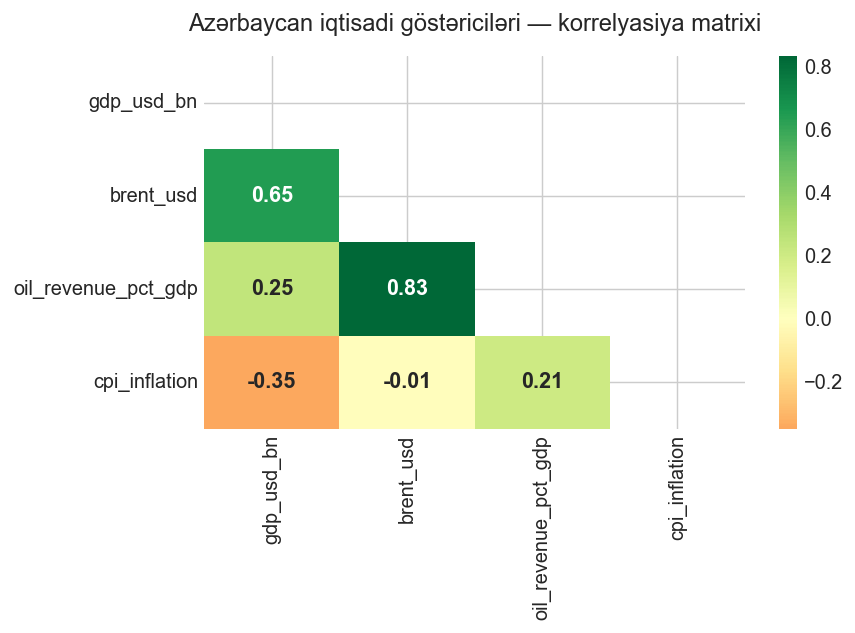

In [4]:
# Əsas statistika
print("=== Deskriptiv statistika ===")
print(df[['gdp_usd_bn','brent_usd','cpi_inflation']].describe().round(2))

# Korrelyasiya matrixi
corr_matrix = df[['gdp_usd_bn','brent_usd','oil_revenue_pct_gdp','cpi_inflation']].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # yalnız alt üçbucaq
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Azərbaycan iqtisadi göstəriciləri — korrelyasiya matrixi', pad=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

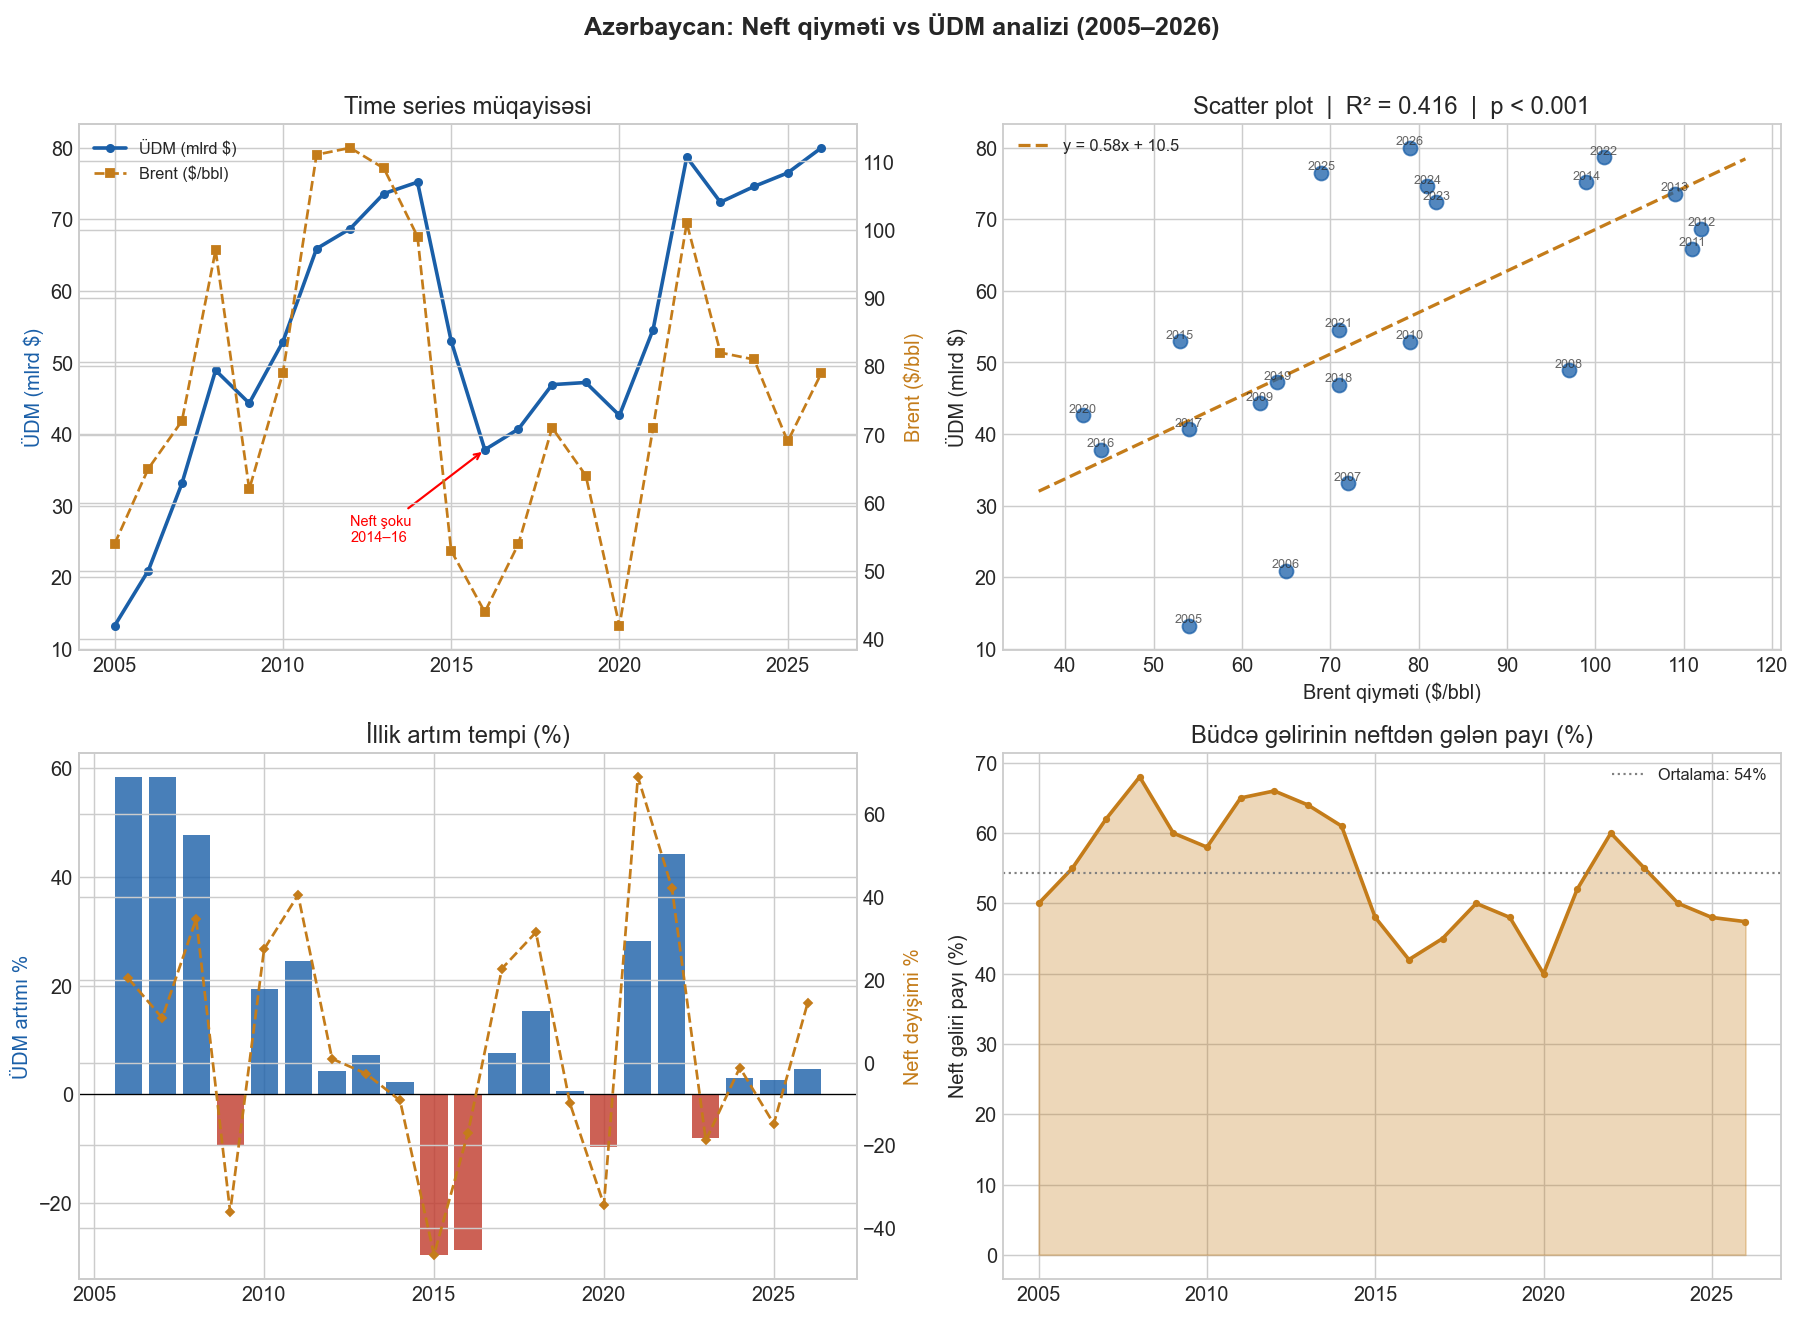

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Azərbaycan: Neft qiyməti vs ÜDM analizi (2005–2026)',
             fontsize=14, fontweight='bold', y=1.01)

# 1) İkili oxlu time series
ax1 = axes[0, 0]
color_gdp, color_oil = '#1a5fa8', '#c47c1a'
ln1 = ax1.plot(df['year'], df['gdp_usd_bn'], color=color_gdp,
               marker='o', ms=4, lw=2, label='ÜDM (mlrd $)')
ax1_r = ax1.twinx()
ln2 = ax1_r.plot(df['year'], df['brent_usd'], color=color_oil,
                 marker='s', ms=4, lw=1.5, ls='--', label='Brent ($/bbl)')
ax1.set_ylabel('ÜDM (mlrd $)', color=color_gdp)
ax1_r.set_ylabel('Brent ($/bbl)', color=color_oil)
ax1.set_title('Time series müqayisəsi')
lines = ln1 + ln2
ax1.legend(lines, [l.get_label() for l in lines], fontsize=9)
ax1.annotate('Neft şoku\n2014–16', xy=(2016, 37.8),
             xytext=(2012, 25), fontsize=8, color='red',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

# 2) Scatter + regression
ax2 = axes[0, 1]
slope, intercept, r, p, se = stats.linregress(df['brent_usd'], df['gdp_usd_bn'])
x_line = np.linspace(df['brent_usd'].min()-5, df['brent_usd'].max()+5, 100)
ax2.scatter(df['brent_usd'], df['gdp_usd_bn'],
            color=color_gdp, alpha=0.75, s=60, zorder=3)
ax2.plot(x_line, slope*x_line + intercept,
         color=color_oil, lw=1.8, ls='--', label=f'y = {slope:.2f}x + {intercept:.1f}')
for _, row in df.iterrows():  # İl etiketləri
    ax2.annotate(str(int(row['year'])),
                 (row['brent_usd'], row['gdp_usd_bn']),
                 fontsize=7, ha='center', va='bottom', alpha=0.7)
ax2.set_xlabel('Brent qiyməti ($/bbl)')
ax2.set_ylabel('ÜDM (mlrd $)')
ax2.set_title(f'Scatter plot  |  R² = {r**2:.3f}  |  p < 0.001')
ax2.legend(fontsize=9)

# 3) İllik artım müqayisəsi
ax3 = axes[1, 0]
df2 = df.dropna(subset=['gdp_growth_pct'])
colors_bar = ['#1a5fa8' if v >= 0 else '#c0392b' for v in df2['gdp_growth_pct']]
ax3.bar(df2['year'], df2['gdp_growth_pct'], color=colors_bar, alpha=0.8, label='ÜDM artımı %')
ax3_r = ax3.twinx()
ax3_r.plot(df2['year'], df2['oil_yoy_change'], color=color_oil,
           marker='D', ms=3, lw=1.5, ls='--', label='Neft dəyişimi %')
ax3.axhline(0, color='black', lw=0.7, ls='-')
ax3.set_title('İllik artım tempi (%)')
ax3.set_ylabel('ÜDM artımı %', color=color_gdp)
ax3_r.set_ylabel('Neft dəyişimi %', color=color_oil)

# 4) Neft gəliri payı
ax4 = axes[1, 1]
ax4.fill_between(df['year'], df['oil_revenue_pct_gdp'],
                 alpha=0.3, color=color_oil)
ax4.plot(df['year'], df['oil_revenue_pct_gdp'],
         color=color_oil, lw=2, marker='o', ms=3)
ax4.axhline(df['oil_revenue_pct_gdp'].mean(), color='gray',
            ls=':', lw=1.2, label=f"Ortalama: {df['oil_revenue_pct_gdp'].mean():.0f}%")
ax4.set_title('Büdcə gəlirinin neftdən gələn payı (%)')
ax4.set_ylabel('Neft gəliri payı (%)')
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig('azerbaijan_oil_gdp_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Model qur
X = df[['brent_usd']].values
y = df['gdp_usd_bn'].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Nəticələr
r2  = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print("=" * 45)
print("  Azərbaycan: Neft → ÜDM Regression Nəticəsi")
print("=" * 45)
print(f"  Koeffisient (slope):  {model.coef_[0]:.3f}")
print(f"  Sabit (intercept):    {model.intercept_:.2f}")
print(f"  R² skoru:             {r2:.4f}  ({r2*100:.1f}%)")
print(f"  MAE:                  ${mae:.2f} mlrd")
print("=" * 45)
print(f"\n  Yorum: Neft $1 artarsa → ÜDM ≈ ${model.coef_[0]:.2f} mlrd artır")
print(f"  ÜDM dəyişkənliyinin {r2*100:.0f}%-i neft qiyməti ilə izah olunur")

# Ssenari proqnozu
print("\n  Ssenari analizi:")
for price in [40, 60, 80, 100, 120]:
    pred = model.predict([[price]])[0]
    print(f"  Neft = ${price}/bbl → Proqnoz ÜDM ≈ ${pred:.1f} mlrd")

  Azərbaycan: Neft → ÜDM Regression Nəticəsi
  Koeffisient (slope):  0.581
  Sabit (intercept):    10.51
  R² skoru:             0.4164  (41.6%)
  MAE:                  $11.05 mlrd

  Yorum: Neft $1 artarsa → ÜDM ≈ $0.58 mlrd artır
  ÜDM dəyişkənliyinin 42%-i neft qiyməti ilə izah olunur

  Ssenari analizi:
  Neft = $40/bbl → Proqnoz ÜDM ≈ $33.7 mlrd
  Neft = $60/bbl → Proqnoz ÜDM ≈ $45.4 mlrd
  Neft = $80/bbl → Proqnoz ÜDM ≈ $57.0 mlrd
  Neft = $100/bbl → Proqnoz ÜDM ≈ $68.6 mlrd
  Neft = $120/bbl → Proqnoz ÜDM ≈ $80.2 mlrd
